In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1440
#runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp4_fixgaussian20_50GW" # _nG30"

student = "Grating_Entire"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 663204
Average function evaluations per core: 3316


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
from scipy.optimize import minimize
from parameters import D1_ND

def get_final(l_min, l_max):
    doppler = l_min / l_max

    def test(v):
        v = v/100
        return np.abs(doppler - D1_ND(v))

    sol = minimize(test, 5)
    final_speed = sol.x[0]
    return final_speed

In [4]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 3

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

grating1 = grating

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6413, dtype=torch.float64), tensor(0.3851, dtype=torch.float64), tensor(0.3264, dtype=torch.float64), tensor(0.0466, dtype=torch.float64), tensor(0.7099, dtype=torch.float64), tensor(5.9552, dtype=torch.float64), tensor(10.3013, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.4197, dtype=torch.float64), tensor(4.5667, dtype=torch.float64)]
[tensor(1.6413, dtype=torch.float64), tensor(0.3851, dtype=torch.float64), tensor(0.3264, dtype=torch.float64), tensor(0.0466, dtype=torch.float64), tensor(0.7099, dtype=torch.float64), tensor(5.9552, dtype=torch.float64), tensor(10.3013, dtype=torch.float64), tensor(0.4197, dtype=torch.float64), tensor(4.5667, dtype=torch.float64)]
0.00011725140238420616
grating_pitch   = 1.641273897979067
grating_depth   = 0.385134391078635
box1_width      = 0.3264483817296625
box2_width      = 0.04658598095748553
box_c

In [5]:
num_plot_points = 500

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating1.wavelength = grating1.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating1,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating1.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals(J1)
    
grating1.wavelength = init_wavelength

In [6]:
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()
average_fom


np.float64(0.00011708889898773912)

Text(0.5, 1.0, "Optimum 3, optimised for $\\lambda' \\in [1, 1.05]$")

<Figure size 1500x750 with 0 Axes>

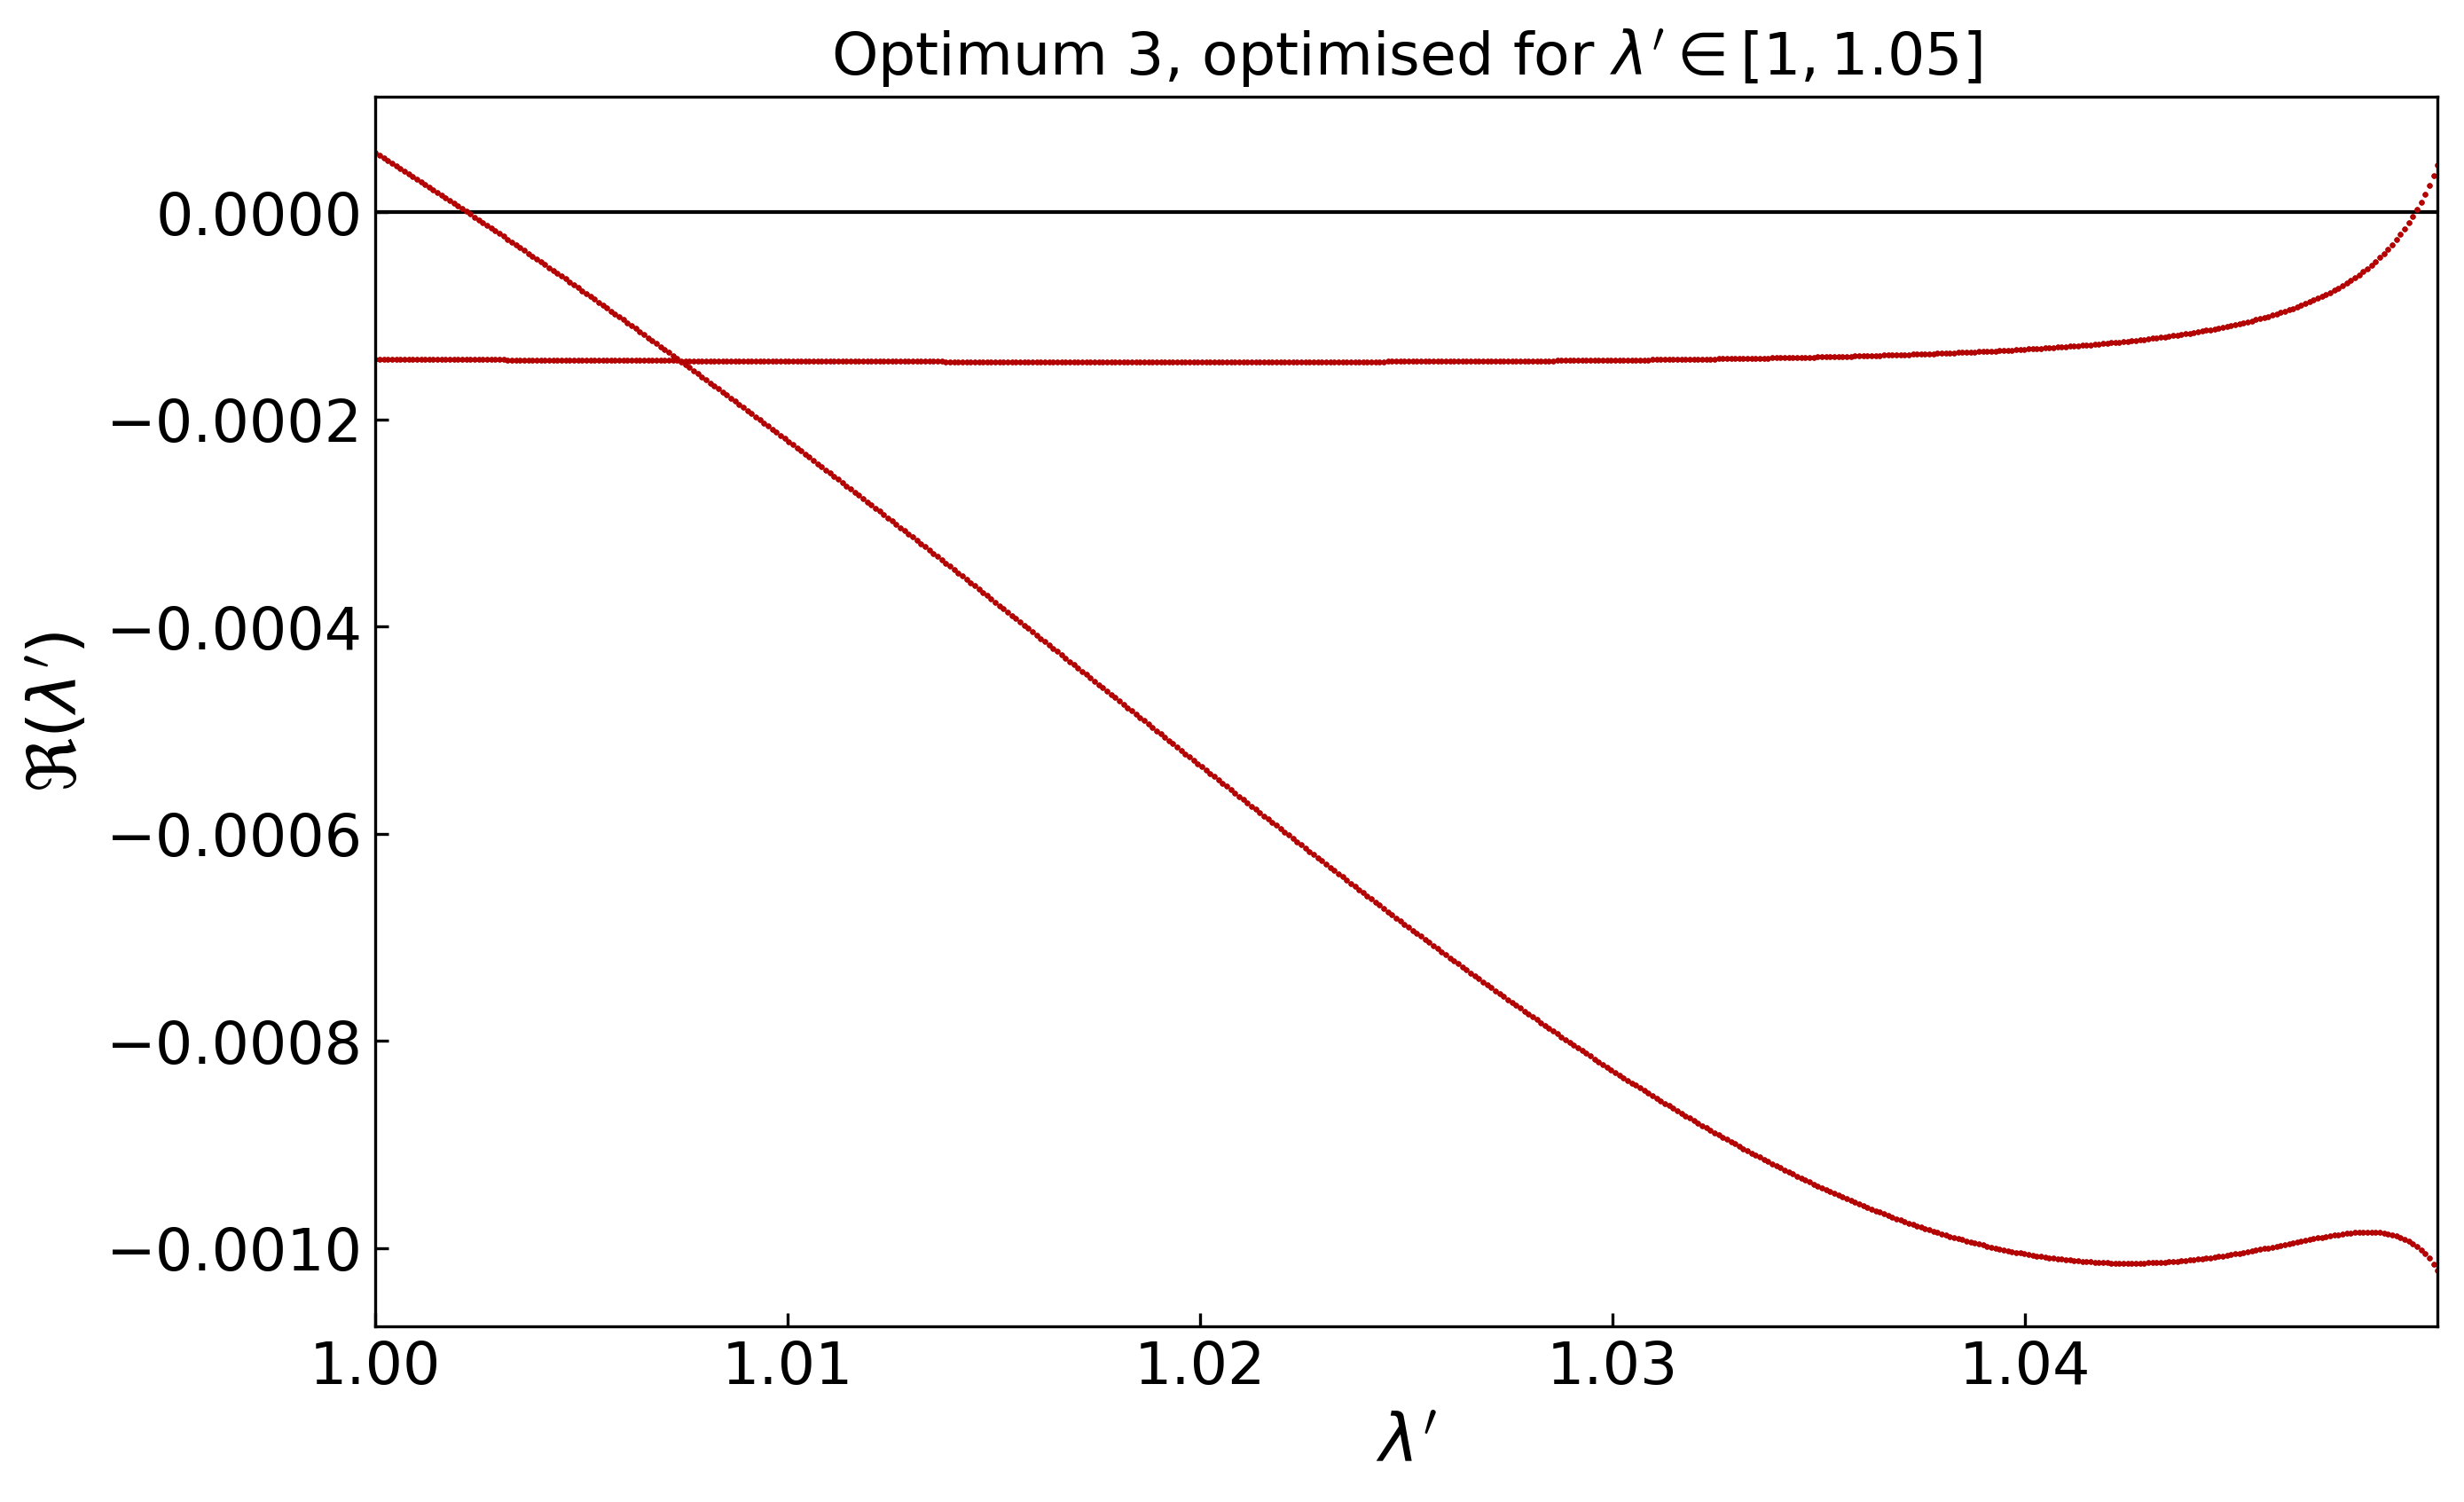

In [7]:
import matplotlib.pyplot as plt
plt.clf()
fig, ax1 = plt.subplots(figsize=(10, 6), nrows=1, ncols=1, dpi = 300)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$")  #color=colorReal  # colored y label
ax1.set(xlabel=r"$\lambda'$")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

ax1.set_title(f"Optimum {optimum_number}, optimised for $\\lambda' \\in [1, 1.05]$")

In [8]:
I0, L, m, c = parameters.Parameters()
optimum_number = 6

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

grating2 = grating

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
0.00010308432310993768
grating_pitch   = 1.6396761254348513
grating_depth   = 0.44432874487544616
box1_width      = 0.34055202066710755
box2_width      = 0.05110622337224755
b

In [9]:
num_plot_points = 500

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating2.wavelength = grating2.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating2,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals(J1)
    
grating2.wavelength = init_wavelength

In [10]:
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()
average_fom

np.float64(0.0001031035509923196)

Text(0.5, 1.0, "Optimum 6, optimised for $\\lambda' \\in [1, 1.05]$")

<Figure size 1500x750 with 0 Axes>

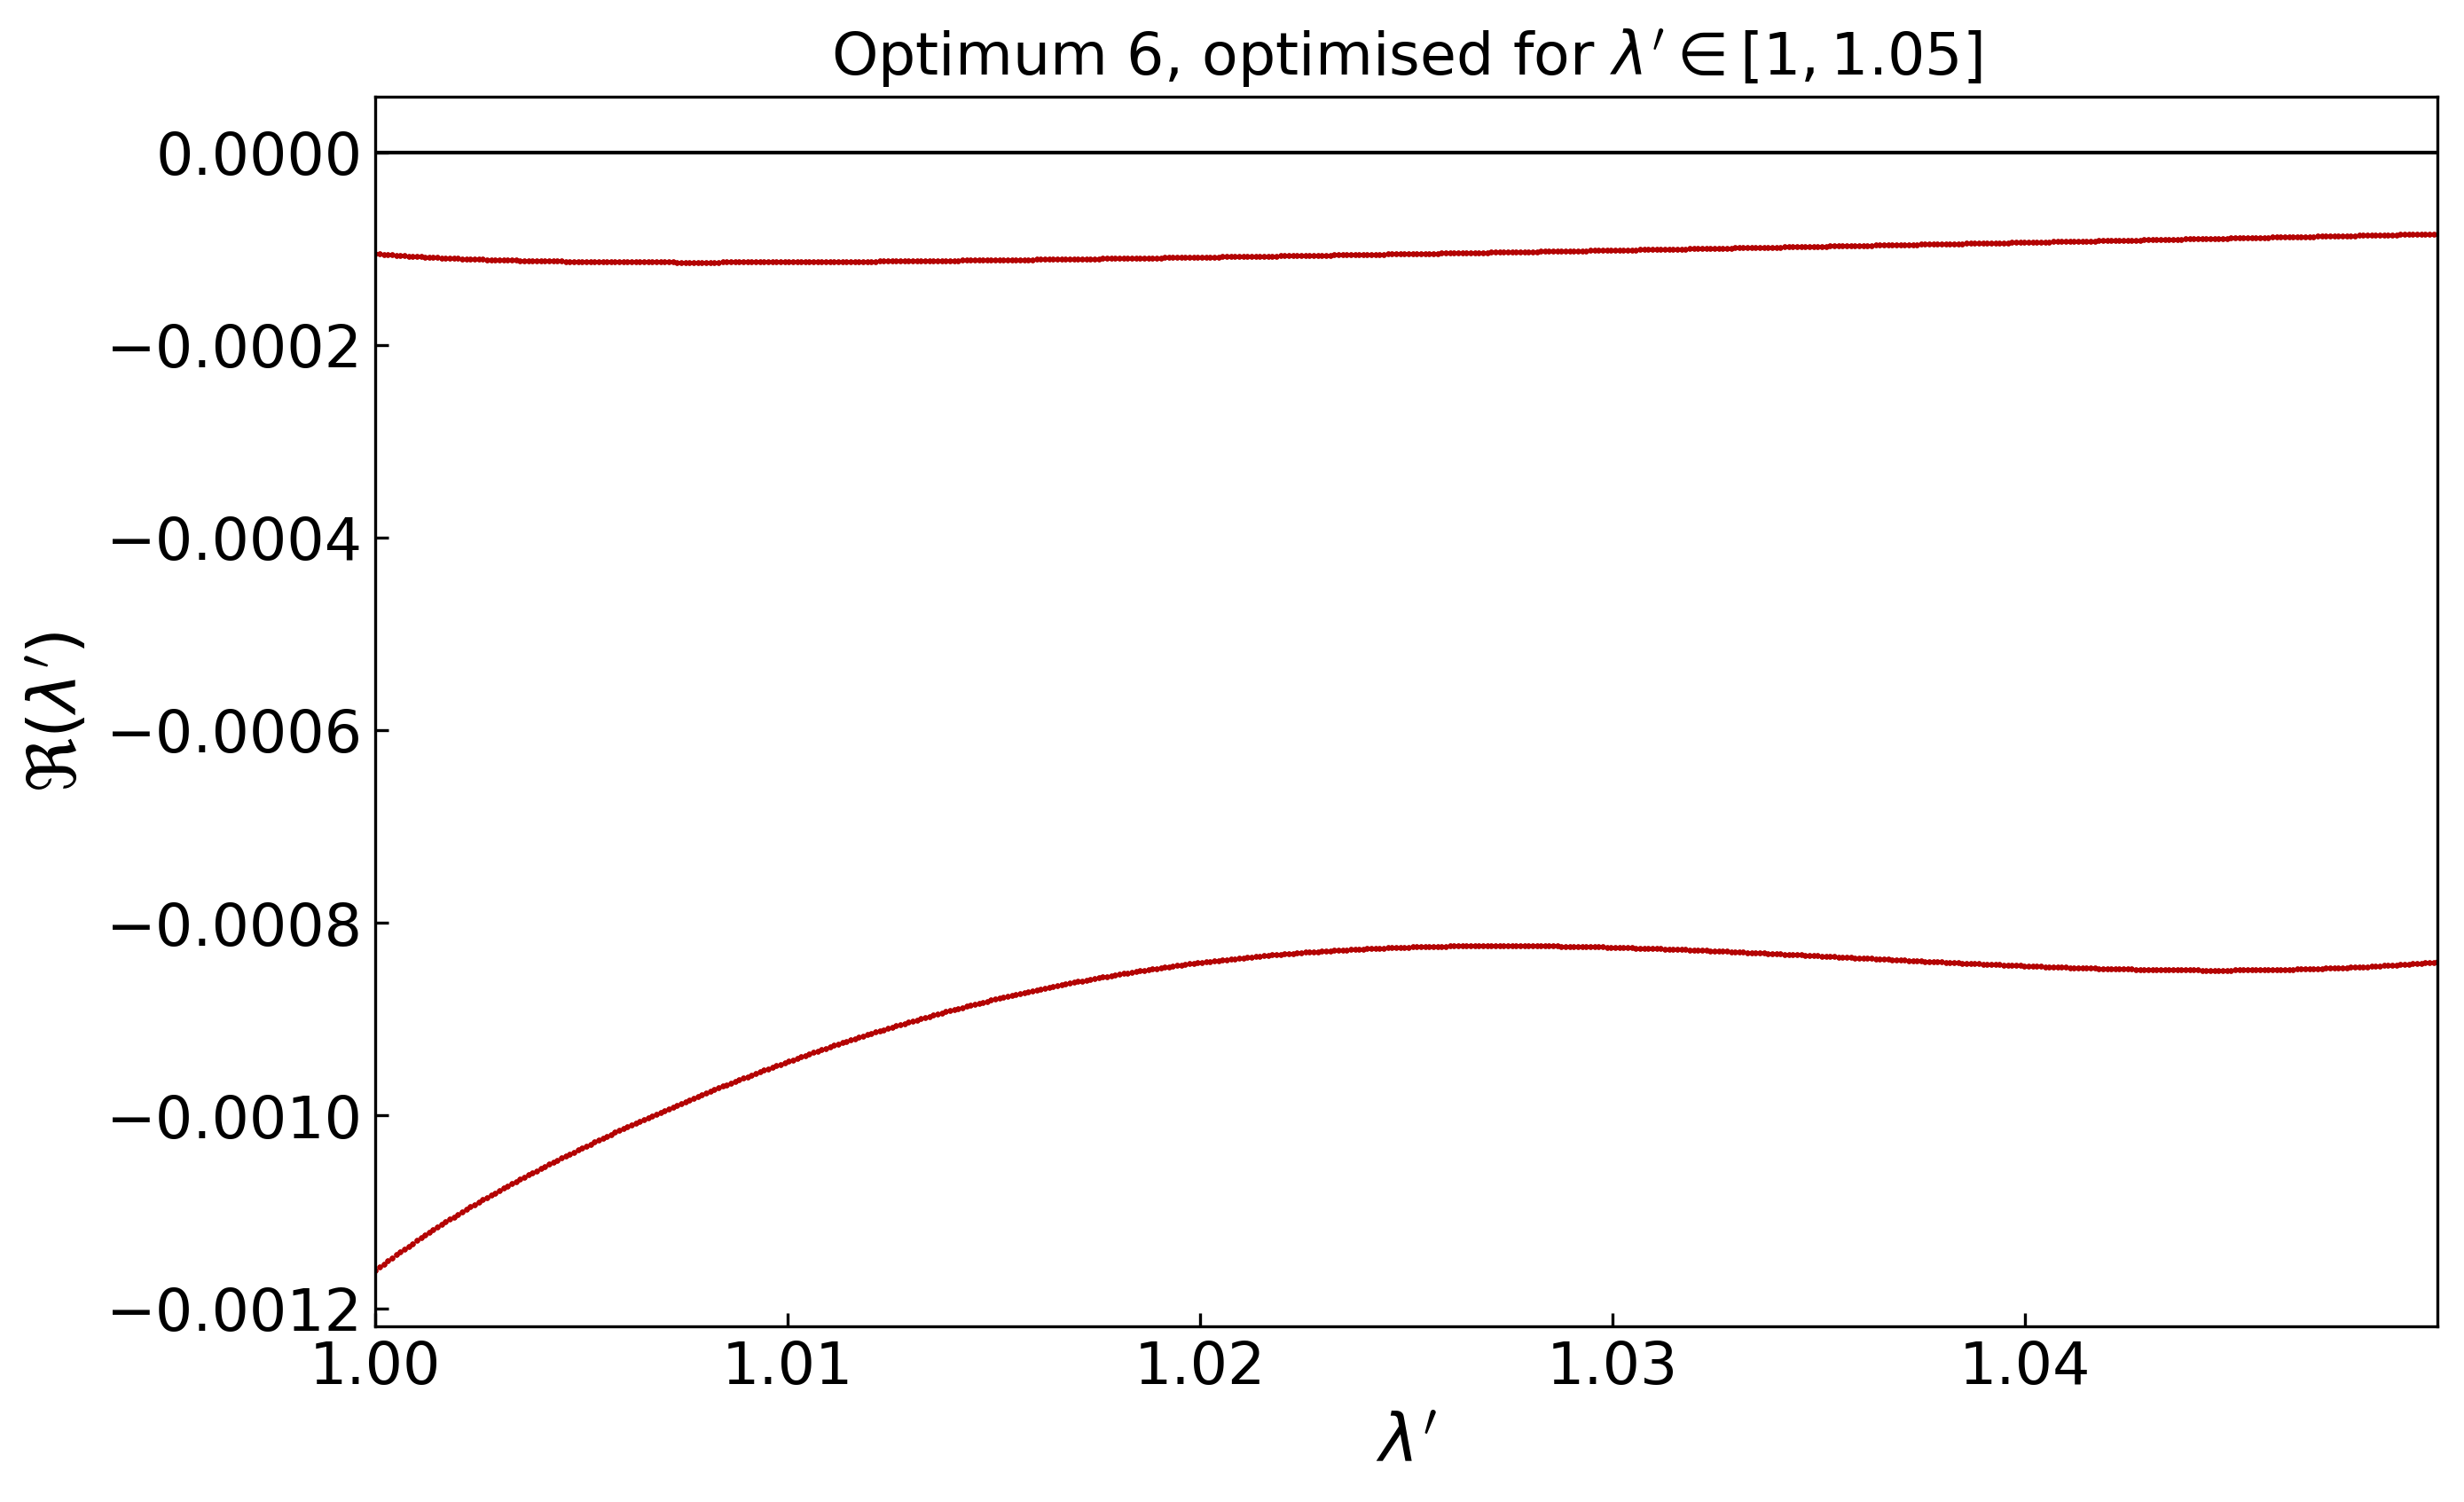

In [11]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(10, 6), nrows=1, ncols=1, dpi = 300)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$")  #color=colorReal  # colored y label
ax1.set(xlabel=r"$\lambda'$")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

ax1.set_title(f"Optimum {optimum_number}, optimised for $\\lambda' \\in [1, 1.05]$")

In [12]:
num_plot_points = 500

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating1.wavelength = grating1.npa.array(lam)
    grating2.wavelength = grating2.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating1,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating1.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    stiffnesses = fom.force_coeff(grating2,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J2 = grating2.npa.concatenate((grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals((J1+ J2)/2)
    
grating1.wavelength = init_wavelength
grating2.wavelength = init_wavelength
eigvals

tensor([[-0.0005+257.6876j, -0.0005+257.9163j, -0.0005+258.1388j,
          ..., -0.0009+207.6838j, -0.0008+207.4945j,
         -0.0008+207.3059j],
        [-0.0005-257.6876j, -0.0005-257.9163j, -0.0005-258.1388j,
          ..., -0.0009-207.6838j, -0.0008-207.4945j,
         -0.0008-207.3059j],
        [-0.0001+32.2204j, -0.0001+32.0155j, -0.0001+31.8127j,
          ..., -0.0001+19.9071j, -0.0001+20.0059j,
         -0.0001+20.1049j],
        [-0.0001-32.2204j, -0.0001-32.0155j, -0.0001-31.8127j,
          ..., -0.0001-19.9071j, -0.0001-20.0059j,
         -0.0001-20.1049j]], dtype=torch.complex128, grad_fn=<CopySlices>)

In [13]:
eigReal = grating.npa.real(eigvals)
fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
average_fom = fom_combined.detach().numpy().mean()
average_fom

np.float64(0.00012261289345718524)

Text(0.5, 1.0, 'Combination of $\\it{overlapping}$ Optimums 3 and 6')

<Figure size 1500x750 with 0 Axes>

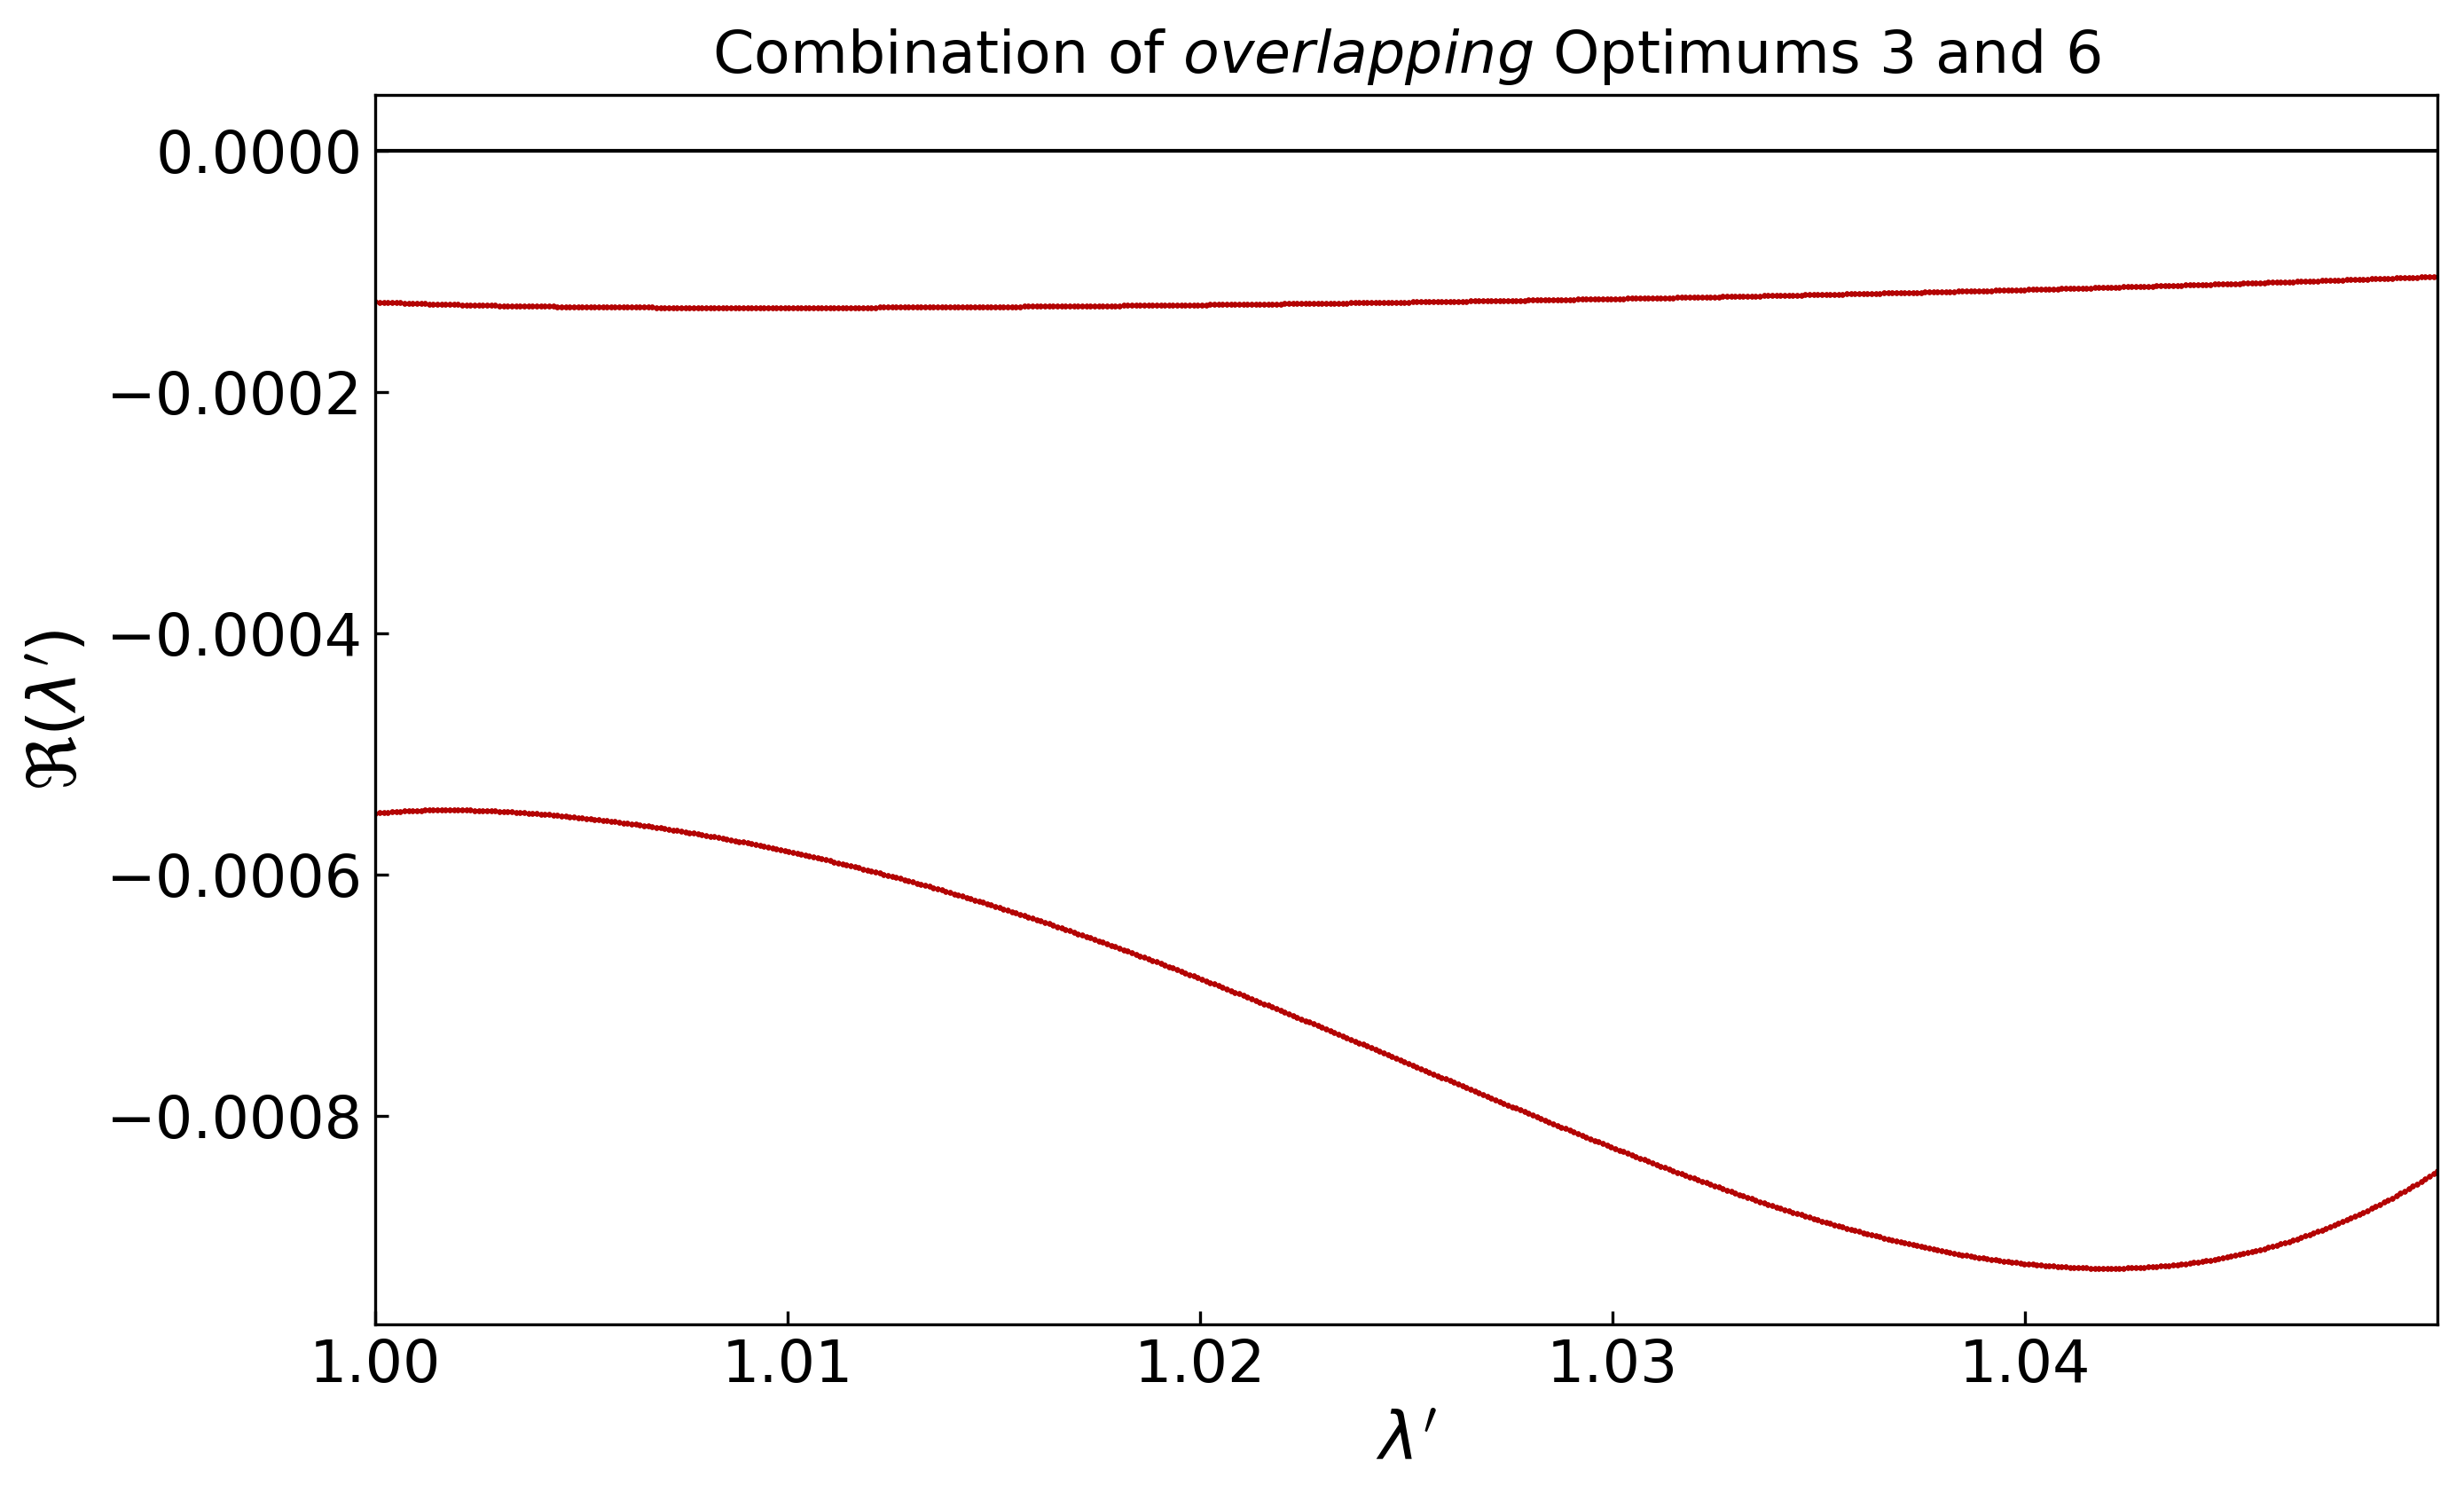

In [14]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(10, 6), nrows=1, ncols=1, dpi = 300)
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda')$")  #color=colorReal  # colored y label
ax1.set(xlabel=r"$\lambda'$")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

ax1.set_title(f"Combination of $\\it{{overlapping}}$ Optimums 3 and 6")